# Notebook 0 — Sort KITTI Images and Train EfficientNetB0

**Project:** Explainable CNN Perception for Autonomous Vehicles  
**Author:** Amith Carmel Anthony Raj

---

Run this notebook **once** before running notebooks 01-04.

What this notebook does:
1. Sorts your KITTI images using YOLO auto-labeling
2. Trains EfficientNetB0 on the sorted images
3. Saves trained weights to `results/trained_weights.weights.h5`

In [9]:
# ── Image PATHS ────────────
PROJECT_ROOT = "C:/CNN_Perception_AV"
KITTI_IMAGES = "D:/kitti/datasets/kitti/images/train"  # your pen drive path


import os
import sys

os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT + "/src")

print(f"Project root : {PROJECT_ROOT}")
print(f"KITTI images : {KITTI_IMAGES}")
print(f"Images found : {len([f for f in os.listdir(KITTI_IMAGES) if f.endswith('.png')])}")

Project root : C:/CNN_Perception_AV
KITTI images : D:/kitti/datasets/kitti/images/train
Images found : 5985


## Step 1 — Sort KITTI Images into Class Folders

Uses YOLOv8 to automatically detect what is in each image and sort them.

In [10]:
# Install YOLO if not already installed
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "ultralytics", "-q"])
print("ultralytics ready")

ultralytics ready


In [11]:
import shutil
from ultralytics import YOLO

DEST = PROJECT_ROOT + "/data/driving_scenes"

# Create destination folders
for cls in ["car", "pedestrian", "cyclist", "background"]:
    os.makedirs(os.path.join(DEST, cls), exist_ok=True)

# YOLO class IDs
# 0=person  1=bicycle  2=car  3=motorcycle  5=bus  7=truck
CAR_IDS        = {2, 3, 5, 7}
PEDESTRIAN_IDS = {0}
CYCLIST_IDS    = {1}

# Load pretrained YOLOv8 nano — downloads ~6MB automatically
yolo   = YOLO("yolov8n.pt")
counts = {"car": 0, "pedestrian": 0, "cyclist": 0, "background": 0}

all_images = [f for f in os.listdir(KITTI_IMAGES) if f.endswith(".png")]
total      = len(all_images)
print(f"Sorting {total} images...")

for i, img_file in enumerate(all_images):
    img_path = os.path.join(KITTI_IMAGES, img_file)
    results  = yolo(img_path, verbose=False)
    detected = set()

    for result in results:
        for box in result.boxes:
            detected.add(int(box.cls))

    if   detected & PEDESTRIAN_IDS: dest_folder = "pedestrian"
    elif detected & CYCLIST_IDS:    dest_folder = "cyclist"
    elif detected & CAR_IDS:        dest_folder = "car"
    else:                           dest_folder = "background"

    shutil.copy(img_path, os.path.join(DEST, dest_folder, img_file))
    counts[dest_folder] += 1

    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{total} processed — "
              f"car:{counts['car']}  "
              f"ped:{counts['pedestrian']}  "
              f"cyc:{counts['cyclist']}  "
              f"bg:{counts['background']}")

print("\nSorting complete!")
print(f"  car        : {counts['car']}")
print(f"  pedestrian : {counts['pedestrian']}")
print(f"  cyclist    : {counts['cyclist']}")
print(f"  background : {counts['background']}")
print(f"  TOTAL      : {sum(counts.values())}")

Sorting 5985 images...
  200/5985 processed — car:135  ped:59  cyc:1  bg:5
  400/5985 processed — car:264  ped:124  cyc:2  bg:10
  600/5985 processed — car:402  ped:182  cyc:2  bg:14
  800/5985 processed — car:533  ped:242  cyc:4  bg:21
  1000/5985 processed — car:658  ped:306  cyc:4  bg:32
  1200/5985 processed — car:781  ped:373  cyc:4  bg:42
  1400/5985 processed — car:923  ped:427  cyc:5  bg:45
  1600/5985 processed — car:1055  ped:490  cyc:6  bg:49
  1800/5985 processed — car:1190  ped:546  cyc:8  bg:56
  2000/5985 processed — car:1318  ped:612  cyc:10  bg:60
  2200/5985 processed — car:1455  ped:669  cyc:12  bg:64
  2400/5985 processed — car:1593  ped:727  cyc:12  bg:68
  2600/5985 processed — car:1721  ped:799  cyc:12  bg:68
  2800/5985 processed — car:1840  ped:877  cyc:12  bg:71
  3000/5985 processed — car:1973  ped:936  cyc:14  bg:77
  3200/5985 processed — car:2112  ped:985  cyc:16  bg:87
  3400/5985 processed — car:2252  ped:1040  cyc:17  bg:91
  3600/5985 processed — car:2

## Step 2 — Train EfficientNetB0

In [12]:
import tensorflow as tf
from model import build_efficientnet, build_dataset, get_callbacks

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.21.0
GPU available: False


In [13]:
# Load dataset
train_ds, val_ds, classes = build_dataset(
    data_dir   = PROJECT_ROOT + "/data/driving_scenes",
    batch_size = 32
)

print(f"\nClass order: {classes}")
print("Make sure this matches CLASS_NAMES in model.py:")
print("['background', 'car', 'pedestrian', 'cyclist']")

Found 5985 files belonging to 4 classes.
Using 4788 files for training.
Found 5985 files belonging to 4 classes.
Using 1197 files for validation.
[INFO] Classes found      : ['background', 'car', 'cyclist', 'pedestrian']
[INFO] Training batches   : 150
[INFO] Validation batches : 38

Class order: ['background', 'car', 'cyclist', 'pedestrian']
Make sure this matches CLASS_NAMES in model.py:
['background', 'car', 'pedestrian', 'cyclist']


In [14]:
# Build model
model = build_efficientnet(freeze_base=False, use_augmentation=True)
print(f"Total parameters: {model.count_params():,}")

Total parameters: 4,416,039


In [15]:
# Train — stops automatically when accuracy stops improving
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 50,
    callbacks       = get_callbacks(PROJECT_ROOT + "/results")
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5174 - loss: 1.2784 - top2_acc: 0.7567
Epoch 1: val_accuracy improved from None to 0.79198, saving model to C:/CNN_Perception_AV/results/best_model.keras

Epoch 1: finished saving model to C:/CNN_Perception_AV/results/best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.6316 - loss: 0.9858 - top2_acc: 0.8642 - val_accuracy: 0.7920 - val_loss: 0.6484 - val_top2_acc: 0.9741 - learning_rate: 1.0000e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7390 - loss: 0.7442 - top2_acc: 0.9487
Epoch 2: val_accuracy improved from 0.79198 to 0.82289, saving model to C:/CNN_Perception_AV/results/best_model.keras

Epoch 2: finished saving model to C:/CNN_Perception_AV/results/best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.7569 - loss: 0.6854 - top2_acc: 0.9528 - val_accuracy: 0.8229 - val_loss: 0.4970 - val_top2_acc: 0.9758 - learning_rate: 1.0000e-04
Epoch 3/50
150/150 ━━

In [16]:
# Save the weights
os.makedirs(PROJECT_ROOT + "/results", exist_ok=True)
weights_path = PROJECT_ROOT + "/results/trained_weights.weights.h5"
model.save_weights(weights_path)
print(f"[OK] Weights saved to: {weights_path}")

[OK] Weights saved to: C:/CNN_Perception_AV/results/trained_weights.weights.h5


## Step 3 — Plot Training History

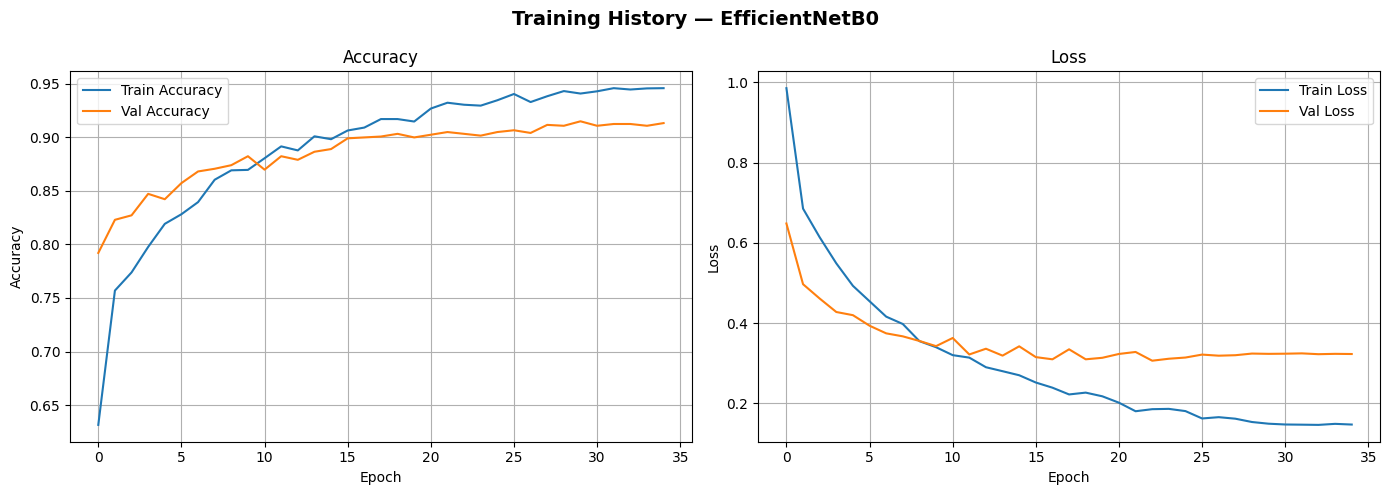

Best validation accuracy: 91.5%


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — EfficientNetB0", fontsize=14, fontweight="bold")

# Accuracy
axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/results/training_history.png", dpi=150, bbox_inches="tight")
plt.show()

best_acc = max(history.history["val_accuracy"])
print(f"Best validation accuracy: {best_acc*100:.1f}%")

## Done!

Trained weights are saved at:
```
C:/CNN_Perception_AV/results/trained_weights.weights.h5
```

Now open notebooks 02, 03, 04 — they will automatically load these weights.